# Week 02 — Exploratory Data Analysis

## Business Problem

We have a dataset from a fictional mobile telephone provider, which includes various features relating to accounts held - e.g. the number of mins of calls used, total charges etc.  Also inlcuded in this data is a 'Churn Label' which tells us whether a customer left the provider (i.e. closed their account).  

We want to know if any of the features available will help us understand why customers leave.  Before we can do this, we need to explore the data so that we can develop understanding of it and perform necessary cleansing so the data is ready for use.

This notebook will walk through the Exploratory Data Analysis (EDA) needed to achieve this.

### Aims
- Load a dataset
- Inspect structure and data types
- Identify duplicates and missing values
- Summarise numeric and categorical variables
- Create initial visualisations
- Note early findings and questions


In [49]:
# import packages

from pathlib import Path

import pandas as pd
print("pandas:", pd.__version__)

import numpy as np
print("numpy:", np.__version__)

import seaborn as sns
print("seaborn:", sns.__version__)

import matplotlib.pyplot as plt

import sweetviz as sv
print("sweetviz:", sv.__version__)

print("Imports successful")

pandas: 3.0.3
numpy: 2.4.6
seaborn: 0.13.2
sweetviz: 2.3.3
Imports successful


In [4]:
# Project paths
PROJECT_DIR = Path(r"C:\Users\serba\ds_projects\bpp_lectures")
COURSE_DOCS = Path(r"C:\Users\serba\OneDrive\BPP_DS")

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

DATA_DIR.mkdir(exist_ok=True)
NOTEBOOK_DIR.mkdir(exist_ok=True)

PROJECT_DIR, COURSE_DOCS, DATA_DIR

(WindowsPath('C:/Users/serba/ds_projects/bpp_lectures'),
 WindowsPath('C:/Users/serba/OneDrive/BPP_DS'),
 WindowsPath('C:/Users/serba/ds_projects/bpp_lectures/data'))

## Read in Data

First step, as always, is to read in your data so that it is available for use.  In the following code we create a path to our dataset's storage location (including the filename), then we use that path in python's in-built read_csv function.  

Note that there are many ways to achieve this, this is only an example (albeit very commonly used).

In [5]:
# create path to data file, then read in
data_path = Path("../data/synthetic_churn.csv")
df = pd.read_csv(data_path)

Once in, let's do a quick check to see how many rows and columns were read in.  Some business knowledge of the data might let you know if this was successful or if there was a problem.

In [6]:
# check shape of the data
df.shape

(6688, 27)

### Bonus:  Automated EDA packages

Rather than write out a lot of code to perform EDA, many common functions can be run automatically using EDA packages such as SweetVis, ydata-profiling, or DataPrep (these last two are not used here as they have not yet caught up with Python 3.13).

#### SweetVis

This package creates a HTML file that must be opened in a browser or similar HMTL viewer:

In [ ]:
sv_report = sv.analyze(df)
sv_report.show_html() 
# creates file "notebooks/SWEETVIZ_REPORT.html" - if it doesn't happen automatically, open this in browser

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Manual EDA

For the rest of this doc, we will perform some manual EDA to demonstrate capabiltiy and explain thoughts.

### Inspect structure and data types

In [8]:
# view column names
df.columns

Index(['Customer ID', 'Churn Label', 'Account Length (in months)',
       'Local Calls', 'Local Mins', 'Intl Calls', 'Intl Mins', 'Intl Active',
       'Intl Plan', 'Extra International Charges', 'Customer Service Calls',
       'Avg Monthly GB Download', 'Unlimited Data Plan', 'Extra Data Charges',
       'State', 'Phone Number', 'Gender', 'Age', 'Under 30', 'Senior', 'Group',
       'Number of Customers in Group', 'Device Protection & Online Backup',
       'Contract Type', 'Payment Method', 'Monthly Charge', 'Total Charges'],
      dtype='str')

In [9]:
# view first five rows of data
df.head()

,Customer ID,Churn Label,Account Length (in months),Local Calls,Local Mins,Intl Calls,Intl Mins,Intl Active,Intl Plan,Extra International Charges,...,Age,Under 30,Senior,Group,Number of Customers in Group,Device Protection & Online Backup,Contract Type,Payment Method,Monthly Charge,Total Charges
0,4444-BZPU,No,1,3,8.0,0.0,0.0,No,no,0.0,...,35,No,No,No,0,No,Month-to-Month,Direct Debit,10,10
1,4444-BZPU,No,1,3,8.0,0.0,0.0,No,no,0.0,...,35,No,No,No,0,No,Month-to-Month,Direct Debit,10,10
2,5676-PTZX,No,33,179,431.3,0.0,0.0,No,no,0.0,...,49,No,No,No,0,Yes,One Year,Paper Check,21,703
3,8532-ZEKQ,No,44,82,217.6,0.0,0.0,No,yes,0.0,...,51,No,No,No,0,Yes,One Year,Direct Debit,23,1014
4,1314-SMPJ,No,10,47,111.6,60.0,71.0,Yes,yes,0.0,...,41,No,No,No,0,No,Month-to-Month,Paper Check,17,177


In [10]:
# get basic descriptions of the columns
df.describe().round(1)

,Account Length (in months),Local Calls,Local Mins,Intl Calls,Intl Mins,Extra International Charges,Customer Service Calls,Avg Monthly GB Download,Extra Data Charges,Age,Number of Customers in Group,Monthly Charge,Total Charges
count,6688.0,6688.0,6687.0,6688.0,6688.0,6688.0,6688.0,6688.0,6688.0,6688.0,6688.0,6688.0,6688.0
mean,32.3,131.0,322.7,51.1,130.1,33.6,0.9,6.7,3.4,47.4,0.8,31.0,1083.6
std,24.6,121.9,288.6,103.6,243.5,76.3,1.4,7.5,12.6,17.0,1.7,16.3,1127.1
min,1.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,5.0,6.0
25%,9.0,31.0,76.8,0.0,0.0,0.0,0.0,1.0,0.0,33.0,0.0,16.0,181.0
50%,29.0,98.0,250.3,0.0,0.0,0.0,0.0,5.0,0.0,47.0,0.0,31.0,647.0
75%,55.0,199.0,497.6,52.0,140.4,16.4,2.0,9.0,0.0,60.0,0.0,43.0,1732.2
max,77.0,918.0,1234.2,1120.0,1372.5,585.8,5.0,43.0,99.0,85.0,6.0,78.0,5574.0


#### Column names and data type info

Let's get some basic info about the data, such as the column names and their data type:

In [32]:
# get info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6688 entries, 0 to 6687
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        6688 non-null   str    
 1   Churn Label                        6688 non-null   str    
 2   Account Length (in months)         6688 non-null   int64  
 3   Local Calls                        6688 non-null   int64  
 4   Local Mins                         6687 non-null   float64
 5   Intl Calls                         6688 non-null   float64
 6   Intl Mins                          6688 non-null   float64
 7   Intl Active                        6688 non-null   str    
 8   Intl Plan                          6688 non-null   str    
 9   Extra International Charges        6688 non-null   float64
 10  Customer Service Calls             6688 non-null   int64  
 11  Avg Monthly GB Download            6688 non-null   int64  
 12  Unl

### Identify duplicates and missing values

There are several things we can do to cleanse data, although much of it requires knowledge of the data that is only obtained through EDA.  For this reason, cleaning and EDA are closely related.

Things we can do first is check for any duplication and/or missing data.

#### Duplicates

First, let's see how many full line duplicates there are.  We could look at duplicate values across each variable, but this is dependent on understanding of the problem and the data.

In [11]:
sum(df.duplicated())

1

It seems there is one...

We can check individual columns, like this:

In [12]:
sum(df.duplicated(['Customer ID']))

1

Where full line duplicates exist we can use the following to drop them.  Notice how the output is saved into a new object.

In [13]:
df_no_duplicate = df.drop_duplicates()
print(df_no_duplicate.shape)

(6687, 27)


If we compare against original df shape to see if rows have been dropped we can see that our original df has more rows.

In [14]:

print(df.shape)

(6688, 27)


In [15]:
# check
sum(df_no_duplicate.duplicated())

0

In [16]:
#now we know it works, repeat for df (for simple object names)
df = df.drop_duplicates()

#### Missing values

An important part of EDA is checking the data for missing values.  Depending on your data, missing values might be expected (even desired) but it's important to know if they are present so action can be taken to handle them if they are not supposed to be there or are not helpful.

e.g. We know from df.info that 'Local Mins' has NULL values... it has less values present than the number of rows in the dataset:

In [17]:
df.notnull().sum() 

Customer ID                          6687
Churn Label                          6687
Account Length (in months)           6687
Local Calls                          6687
Local Mins                           6686
Intl Calls                           6687
Intl Mins                            6687
Intl Active                          6687
Intl Plan                            6687
Extra International Charges          6687
Customer Service Calls               6687
Avg Monthly GB Download              6687
Unlimited Data Plan                  6687
Extra Data Charges                   6687
State                                6687
Phone Number                         6687
Gender                               6687
Age                                  6687
Under 30                             6687
Senior                               6687
Group                                6687
Number of Customers in Group         6687
Device Protection & Online Backup    6687
Contract Type                     

We can also confirm this using:

In [47]:
df.isnull().sum() 

Customer ID                          0
Churn Label                          0
Account Length (in months)           0
Local Calls                          0
Local Mins                           1
Intl Calls                           0
Intl Mins                            0
Intl Active                          0
Intl Plan                            0
Extra International Charges          0
Customer Service Calls               0
Avg Monthly GB Download              0
Unlimited Data Plan                  0
Extra Data Charges                   0
State                                0
Phone Number                         0
Gender                               0
Age                                  0
Under 30                             0
Senior                               0
Group                                0
Number of Customers in Group         0
Device Protection & Online Backup    0
Contract Type                        0
Payment Method                       0
Monthly Charge           

This indeed confirms that Local Mins has a NULL value.  Lets have a look at that row:

The following filters the 'Local Mins' column for missing values and uses the result to filter the df dataframe to just those rows (or single row in this case):

In [18]:
df[df['Local Mins'].isnull()]

,Customer ID,Churn Label,Account Length (in months),Local Calls,Local Mins,Intl Calls,Intl Mins,Intl Active,Intl Plan,Extra International Charges,...,Age,Under 30,Senior,Group,Number of Customers in Group,Device Protection & Online Backup,Contract Type,Payment Method,Monthly Charge,Total Charges
5,2956-TXCJ,No,62,184,NaN,310.0,694.4,Yes,yes,0.0,...,51,No,No,No,0,No,One Year,Direct Debit,28,1720


From this we can determine that there is only one row with a missing value in 'Local Mins' (shows here as 'NaN').  We want to take action to rectify this and, once done, we need to check that it worked as expected.  

We intend to impute a value to replace the NULL.  If our action works, filtering 'Local Mins' for NULL values won't return any results, so how do we check?

Simple - we know that the missing value is on row 5 (from last code node), so we will filter for this row specifically:

In [50]:
df.loc[5]

Customer ID                             2956-TXCJ
Churn Label                                    No
Account Length (in months)                     62
Local Calls                                   184
Local Mins                                    NaN
Intl Calls                                  310.0
Intl Mins                                   694.4
Intl Active                                   Yes
Intl Plan                                     yes
Extra International Charges                   0.0
Customer Service Calls                          0
Avg Monthly GB Download                         3
Unlimited Data Plan                           Yes
Extra Data Charges                              0
State                                          WV
Phone Number                             330-8173
Gender                                       Male
Age                                            51
Under 30                                       No
Senior                                         No


We could replace the missing value by simply adding the value in, assuming we know what the value should be... e.g. if we know the value should be 999, or we have a business reason to give it this value, then we would use:

df.loc[5,'Local Mins'] = 999 # this replaces NULL with the value 999

BUT, the chances are that we may not know what that missing value should be, so we need to impute it using a value we can determine from the rest of the available data.  

One method could be to use an average value for all missing values in that column - i.e. we would calculate an average based on the non-missing values of 'Local Mins' then use that value to replace the missing values.  

Among other things, we could use the mean or the median - deciding which needs judgment based on knowledge of the data.  For instance, if there are there outliers we may be best to use the median.  Let's do that:


In [19]:
df.loc[5,'Local Mins'] = df['Local Mins'].median()

Let's check the value was input correctly:

In [20]:
df.loc[5]

Customer ID                             2956-TXCJ
Churn Label                                    No
Account Length (in months)                     62
Local Calls                                   184
Local Mins                                  250.4
Intl Calls                                  310.0
Intl Mins                                   694.4
Intl Active                                   Yes
Intl Plan                                     yes
Extra International Charges                   0.0
Customer Service Calls                          0
Avg Monthly GB Download                         3
Unlimited Data Plan                           Yes
Extra Data Charges                              0
State                                          WV
Phone Number                             330-8173
Gender                                       Male
Age                                            51
Under 30                                       No
Senior                                         No


Success! We've just imputed the median value of 250.4 into the NULL value in row 5 of 'Local Mins'.

As an alternative, we could have simply dropped any rows containing missing data but the decision to do this must be based on knowledge of the problem, the business, and the data.  Obviously, simply dropping rows could lose potentially valuable data from the dataset.

e.g. df = df.dropna()  # this code drops rows with any 'na' (aka NULL) values

### Summarise numeric and categorical variables

Referring back to our business problem, 'Churn Label' seems to be the target variable - that is the variable that tells us if a customer left.

This is likely a categorical variable - let's look closer:



In [23]:
print(df['Churn Label'].value_counts())

Churn Label
No     4891
Yes    1796
Name: count, dtype: int64


We can build upon this to get a % view of the distribution using 'normalize-True'.  So, churn as a % of our dataset:

In [25]:
print(df['Churn Label'].value_counts(normalize=True) * 100)

Churn Label
No     73.141917
Yes    26.858083
Name: proportion, dtype: float64


OK, it looks like our 'Churn Label' is indeed categorical - it has only two values, Yes/No.  We know that around 26% of people left, but we are typically visual beings and visualising this particular variable might give us a better feel of the distribution...

## Create initial visualisations

Much valuable information about the data can be found by visualising it.  Assessing the distribution of the data, as well as any correlation, can help identify patterns, trends, and potential data issues.

Let's create a column chart of 'Churn Label':

<Axes: xlabel='Churn Label', ylabel='count'>

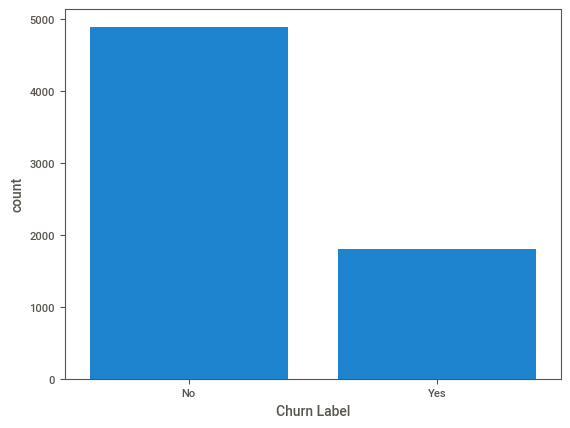

In [28]:
sns.countplot(data=df, x='Churn Label')

OK, this tells a story rather than simply giving numbers.  From this chart it is clear that churn is actually quite high!

### Histograms

A histogram can show us how continuous numerical ata is distributed throughout our dataset.  Let's remind ourselves of what is in the data:

In [30]:
df.head()

,Customer ID,Churn Label,Account Length (in months),Local Calls,Local Mins,Intl Calls,Intl Mins,Intl Active,Intl Plan,Extra International Charges,...,Age,Under 30,Senior,Group,Number of Customers in Group,Device Protection & Online Backup,Contract Type,Payment Method,Monthly Charge,Total Charges
0,4444-BZPU,No,1,3,8.0,0.0,0.0,No,no,0.0,...,35,No,No,No,0,No,Month-to-Month,Direct Debit,10,10
2,5676-PTZX,No,33,179,431.3,0.0,0.0,No,no,0.0,...,49,No,No,No,0,Yes,One Year,Paper Check,21,703
3,8532-ZEKQ,No,44,82,217.6,0.0,0.0,No,yes,0.0,...,51,No,No,No,0,Yes,One Year,Direct Debit,23,1014
4,1314-SMPJ,No,10,47,111.6,60.0,71.0,Yes,yes,0.0,...,41,No,No,No,0,No,Month-to-Month,Paper Check,17,177
5,2956-TXCJ,No,62,184,250.4,310.0,694.4,Yes,yes,0.0,...,51,No,No,No,0,No,One Year,Direct Debit,28,1720


Starting from left to right in our dataset, let's have a look at account length:

<Axes: xlabel='Account Length (in months)', ylabel='Count'>

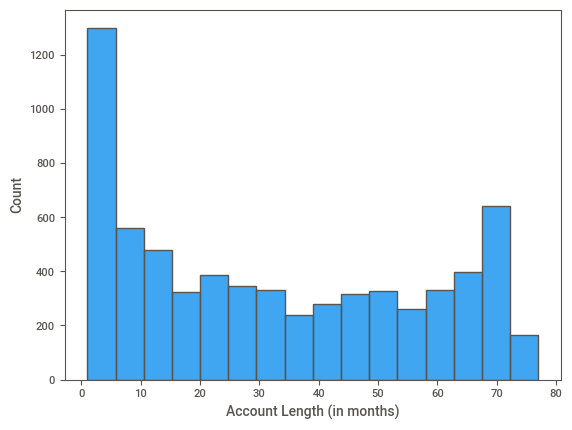

In [31]:
sns.histplot(data=df, x='Account Length (in months)')


The histogram has 'binned' our data into bins of up to 5 months.  For example, the first 'bin' (0<=5) suggests there are almost 1300 accounts that are with the telephone company less than 5 months before terminating their contract.  This is quite a finding, although it doesn't tell us anything about *why* they closed their accounts.

Let's pick another variable from our dataset - something that might give us an indication of what might be causing churn...

Q. Does age make a difference?

### Box Plots

A box plot can show how numerical data is related to a categorical variable.  In this instance, it might help us understand how the age of the account holders is distributed between those that leave and those that stay:

<Axes: xlabel='Churn Label', ylabel='Age'>

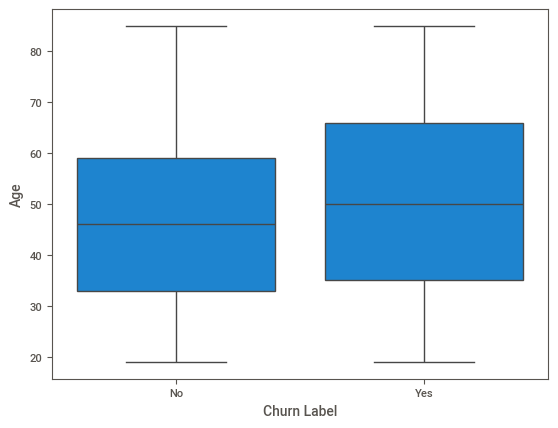

In [32]:
sns.boxplot(data=df, x='Churn Label', y='Age')

That is really interesting!  It seems that the median age of those that leave (Yes) is higher and has a wider distribution than those that stay.  This suggests that the majority of leavers are typically older than those that stay - this might be something to report back to senior leaders so they could devise an offer to retain older customers.

Another option for visualising this data may be a...

### Violin Plot

E.g.

<Axes: xlabel='Churn Label', ylabel='Age'>

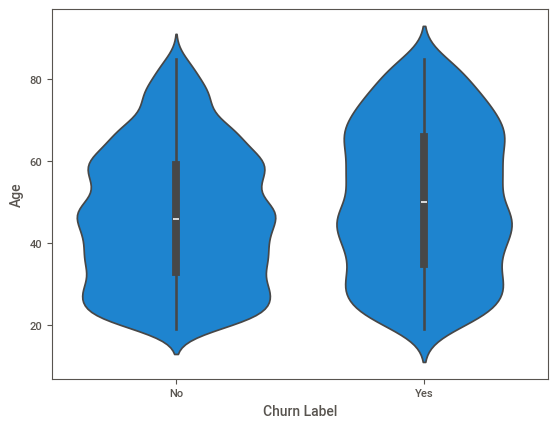

In [ ]:
sns.violinplot(data=df, x='Churn Label', y='Age')

This plot tells us similar things to the box plot, although it also conveys how customer ages fluctuate.  E.g. the age of those who remain drops off quite sharply at 60, further supporting the understanding that younger customers tend to stay with this provider.

Also, given that the 'Yes' plot is relatively uniform across ages, this may indicate that age isn't a factor in why people are leaving...

OK, looking back at our column names we find a variable containing the number of calls a customer made to customer service.  That sounds like it might be relevant, so let's look at that...

Given we are again looking at the relationship of a numerical and a categorical variable, let's use another box plot:

<Axes: xlabel='Churn Label', ylabel='Customer Service Calls'>

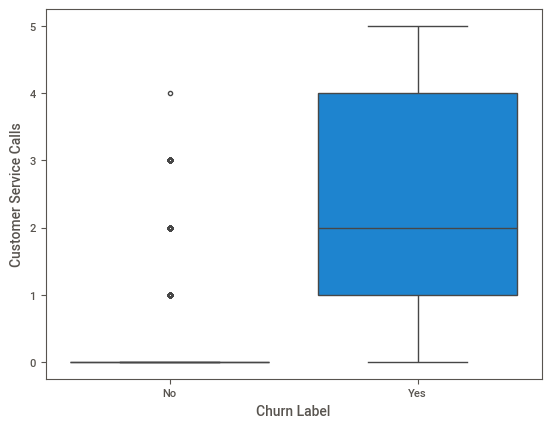

In [34]:
sns.boxplot(data=df, x='Churn Label', y='Customer Service Calls')

Boom!  This indeed looks relevant!  Let's try with a violin plot:

<Axes: xlabel='Churn Label', ylabel='Customer Service Calls'>

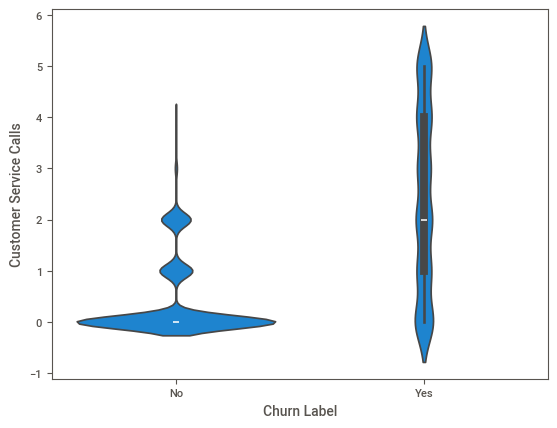

In [35]:
sns.violinplot(data=df, x='Churn Label', y='Customer Service Calls')

Hardly anyone that stays calls customer service, yet those that are leaving almost always do (only a very small amount leave with 0 calls to customer service).  This may form another recommendation to seniors - to look into what issues are being reported on those calls and to take action to prevent them.

Again, this helps us understand but doesn't tell us why customers leave.

Q. what kind of contracts are related to churn?

### Bar Charts

<Axes: xlabel='Contract Type', ylabel='count'>

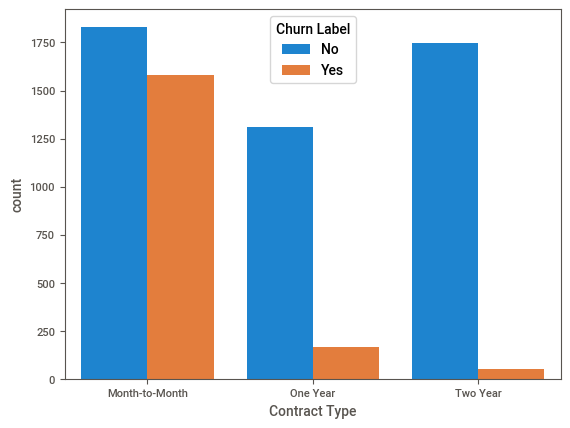

In [36]:
sns.countplot(data=df, x='Contract Type', hue='Churn Label')

This is quite a stark finding... the vast majority of leavers have a month-to-month contract.  Some business knowledge needs to be considered here - i.e. someone on a year long contract cannot easily leave after 5 months!  

However, there are comparatively few leavers after one year, and even less after two years.  This suggests that those that choose longer term contracts are generally more likely to stay, which raises the possibilty that contract type might be helpful if trying to predict whether a customer will leave in less than a year.  

It also raises further questions for senior leaders, such as whether more can be done to entice people into longer term contracts, and/or whether a customer survey could be completed to see why people are choosing month-to-month contracts.

Let's quickly confirm numbers:


In [51]:
pd.crosstab(
    df['Contract Type'],
    df['Churn Label']
)

Churn Label,No,Yes
Contract Type,,
Month-to-Month,1832,1579
One Year,1312,167
Two Year,1747,50


In [52]:
pd.crosstab(
    df['Contract Type'],
    df['Churn Label'],
    normalize='index'
) * 100

Churn Label,No,Yes
Contract Type,,
Month-to-Month,53.708590,46.291410
One Year,88.708587,11.291413
Two Year,97.217585,2.782415


Wow!  53.7% of customers with a month-to-month contract leave within a year!!  

One thing that is likely relevant is how churn is related to what people pay.  It seems there are several variables that are relevant here: Extra Data Charges', 'Monthly Charge', and 'Total Charges'

Let's look at these individually:

<Axes: xlabel='Extra Data Charges', ylabel='Count'>

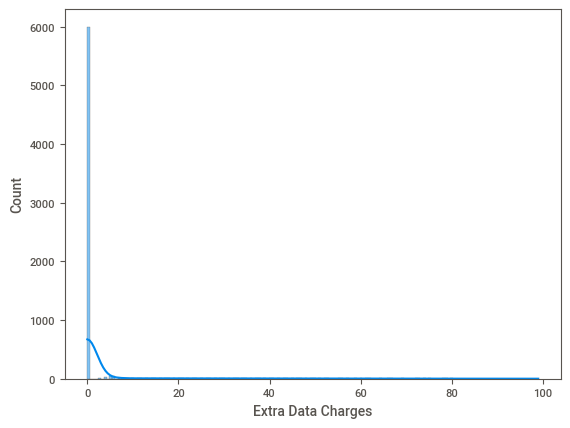

In [37]:
sns.histplot(df['Extra Data Charges'], kde=True)

It seems that there are hardly any accounts paying extra data charges - it's not likely that this will be helpful.

<Axes: xlabel='Monthly Charge', ylabel='Count'>

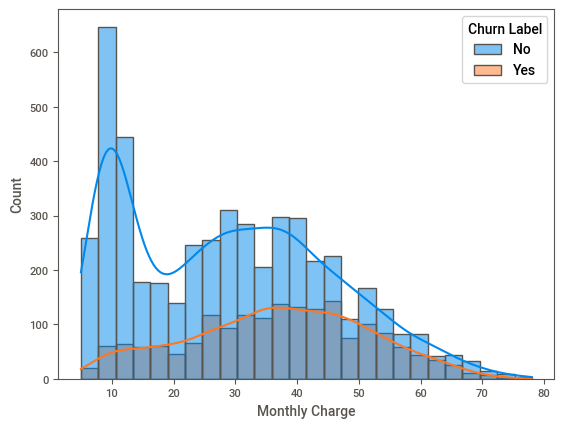

In [54]:
sns.histplot(df, x='Monthly Charge', hue='Churn Label', kde=True)

OK, so for those that stay there is a large number of accounts paying around 10 per month, and there is a strange dip at 20 before charges slightly increase and become relatively stable.  Maybe there is something to investigate around contract pricing.

Interestingly, the majority of people that leave do not have such low monthly charges - most of them seem to be between 25 and 50 per month.  Maybe lower prices could help retention?  Maybe something to show senior leaders...

<Axes: xlabel='Total Charges', ylabel='Count'>

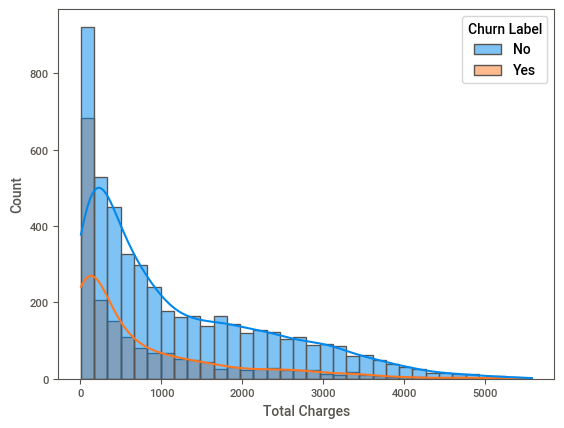

In [56]:
sns.histplot(df, x='Total Charges', hue='Churn Label', kde=True)

Total charges has a completely different view - it seems there is little difference in the distribution of total charges between those who churn. Is this because, overall, people are paying around the same regardless of whether they are on monthly or annual contracts?  Maybe needs further investigation.

### Correlation

We can have a wider look at the dataset to see which variables are correlated - that is, whether there is a relationship (positive or negative) between any pair of numeric variables.  Note that string variables are unsuitable for this.

<Axes: >

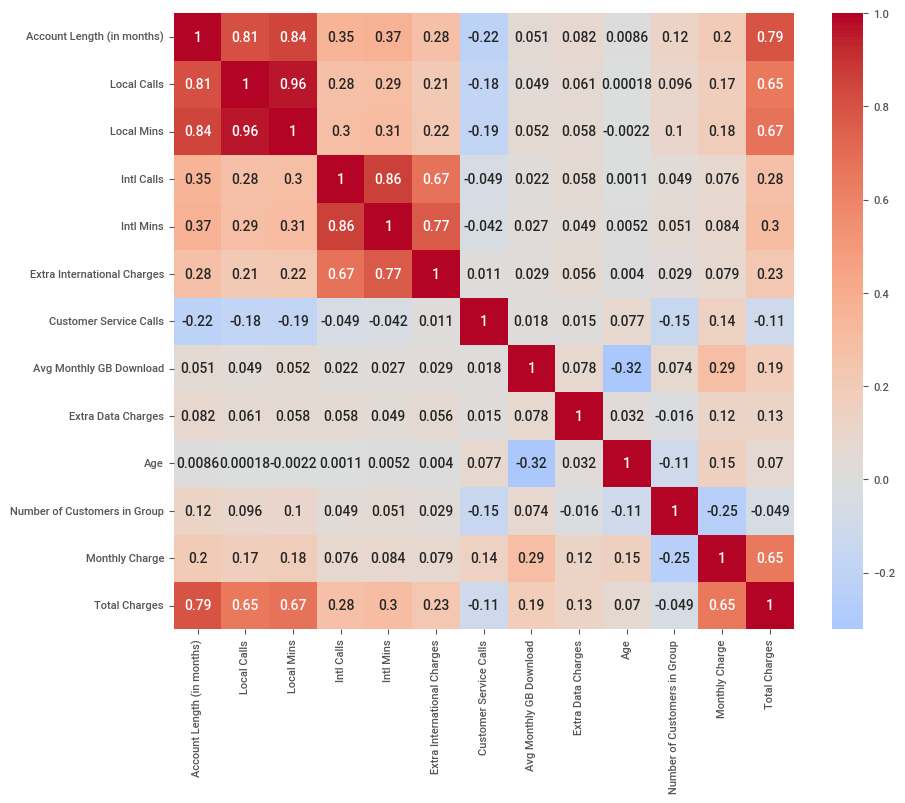

In [ ]:
numeric_df = df.select_dtypes(include='number') # select only numeric columns from df

plt.figure(figsize=(10, 8)) # make the plot larger thand default so it displays well enough to read

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0 # force it to ensure colours are applied around 0 (anything below should be blue, anything above red)
)

So, many columns are correlated that we would expect to be - i.e. number of international calls and international minutes and international charges could be expected to be related (as they are almost telling the same story).

Also, Age and monthly downloads are quite telling: at -0.32 this is telling us that older people tend to download less data.  This may be true because of how people use their phones and suggests that older people do not use data in quite the same ways (or as much) as younger people.  

Numbers that hover around 0 tend not to be correlated, and therefore wouldn't be good predictors of certain things.  For example, let's assume total charges data is missing for a significant number of accounts.  If we used monthy charges, local mins, local calls, and account length, we might be able to make a reasonable prediction of total charges.

Importantly, it seems that account length is highly correlated to local calls, local mins, and total charges.  It is also slightly correlated to international calls/mins and customer service calls.  With this in mind, maybe these variables could be used as predictors of whether a customer will churn... 

We could try to visualise the relationship between some of these interesting numeric variables using a scatterplot:

<Axes: xlabel='Total Charges', ylabel='Monthly Charge'>

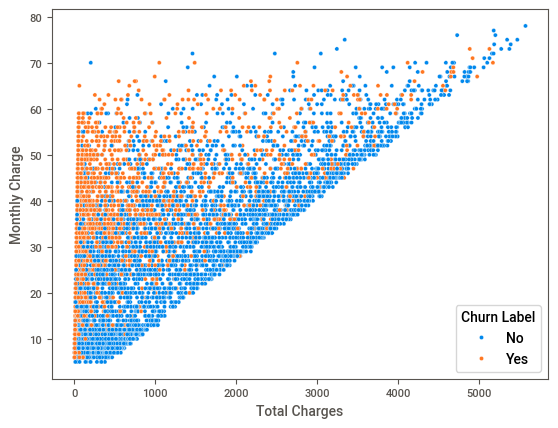

In [58]:
sns.scatterplot(x='Total Charges', y='Monthly Charge', data=df, hue='Churn Label')

So, some key points from our chart:
* There is a clear boundary (the diagnal line) which represents the limit of what people are being charged.  As expected, this limit increases as monthly charge increases.
* Those that remain seem to congregate to the right side of the chart, indicating that they are actually paying *more* than those that leave.  E.g. 'No' customers being charged 30 per month seem to be paying up to ~2000 in total, where 'Yes' customers are relatively low at 500.

Naturally, there are exceptions to this and it seems that the higher the monthly charge the more spread out they are.  Also, there may be a business reason for this.  E.g. it could be that 'Total Charge' reflects the whole year and not a monthly charge - I do not know this from the data alone.  It would be recommended that a discussion take place with seniors to confirm if they are aware of the reason.

# Categorical Variables (only)

Let's get a little more complicated... we want to know if there is a relationship between contract type and churn.  In our dataset these are both categorical variables, which typically rely on visualisations such as bar/column charts (e.g. relationship between a categorical and a numeric, or a frequency count of a categorical variable).  

These only tell us so much, so what if we want to know if two categorical variables are likely to be independent (i.e. unrelated)?  E.g. can we assess if contract type is likely to be independent of churn?

Simply, yes we can although this is a little more complicated than above... we can use a **Chi-squared test** to determine the probability that two categorical variables are related, but how it does this requires a little explanation.


You we really to know from a Chi-squared test:

    Is churn related to contract type, or are any differences just random chance?

It works by completing the following steps:
1. Create a contingency table 

    This table summarises our categorical table into counts.  E.g. (fictional numbers used for the example):

    Contract Type	No Churn	Churn	Total
    Month-to-Month	580	        420	    1000
    One Year	    890	        110	    1000
    Two Year	    970	        30	    1000
    Totals          2440        560     3000

2. Create a NULL hypothesis

    In other words, we assume that contract type and churn are completely independent.  
    
    The alternative hypothesis here is that they are related, which we can accept if the chi-squared test provides evidence that disproves the NULL hypothesis.

    Assuming the null hypothesis is true and that theya re completely independent, we should expect to see the same rate of churn in each contract type.  Even without going further we can see that this cannot be true but chi-squared can help us quantify this.

    Continuing with the above example figures, overall churn rate is:
        Number of Churners /  Total number of customers
        560 / 3000 = 0.187
        18.7%
    
    For our variables to be independent, for an overall churn rate of 18.7% we would expect the contingiency table to look like this:

    Contract Type	Expected No Churn	Expected Churn  Total
    Month-to-Month	813	                187             1000
    One Year	    813	                187             1000
    Two Year	    813	                187             1000
    Totals          2439                561             3000

    These are our expected frequencies.

3. Compare expected vs actual frequencies

    E.g. month to month expected is 187, yet the actual is 420.  This is a huge difference.  Two year is just as stark with an expected of 187 and an actual of 30.

    Chi-squared measures the total discrepancy between all the expected and actual values.  The formula for this is:

    $$
    χ2=∑E(O−E)2​
    $$

    Explained: for every row in the dataset, deduct expected from observed (aka actual), square that value (to make it positive), then didvide by the expected value.  Sum all of these values and you are left with $ x^2 $.  

    Large differences mean large Chi-square statistic.
    Small differences mean small Chi-square statistic.

4. Convert our chi-squared statistic ($x^2$) to a **p-value**

   By doing this we are effectively asking how likely it would be to see this difference ($x^2$) if contract type and churn were actually unrelated?  

   Or, another way, what is the probability that our null hypothesis is true? 

   We won't cover converting to a p-value here - it is generated by our chi-squared function:

In [60]:
# import chi-squared function
from scipy.stats import chi2_contingency

# create contingiency table
table = pd.crosstab(
    df['Contract Type'],
    df['Churn Label']
)

# use chi-squared function to create chi-squared statistic (chi2), p-value (p), degrees of freedom (dof), and expected frequencies
chi2, p, dof, expected = chi2_contingency(table)

print(f"p-value: {p}")

p-value: 7.127758941425194e-298


Wow... this number effectively means there are 297 zeros in front of 7.1277... This number is so fantastically small that it is practically 0.

A p-value below 0.05 is generally accepted as confirmation that the probability of the observed being random is so low that we can reject the null hypothesis.  Here, even if we went further and used <0.02, our result is so small that it would still allow us to reject the null hypothesis.

**For this reason, we can accept our alternative hypothesis that Contract Type and Churn Label are related!**

Again, this does not mean causation though!!

## Findings

TBC